# Cicero Letters – Minimal Notebook for Exploration

Dieses minimal gehaltene Notebook dient als Experimentierumgebung für:

- **TF-IDF**
- **gensim Topic Modelling (LDA)**

Es arbeitet direkt mit bereits analysierten **`.conllu`-Dateien** und ist bewusst einfacher als die grosse Pipeline mit LatinCy und BERTopic.

## Lernziele

Nach diesem Notebook sollt ihr:

1. lemma-basierte Texte aus `.conllu` laden können
2. TF-IDF für Briefe berechnen können
3. ähnliche Briefe identifizieren können
4. mit **gensim LDA** Topics erzeugen und interpretieren können
5. die Auswirkungen von Parametern reflektieren können

## Hinweis

Dieses Notebook ist **explorativ**. Die Ergebnisse sind interpretierbar, aber nicht automatisch „wahr“. Gerade bei Topic Modelling solltet ihr immer prüfen, ob die Topics historisch sinnvoll sind.

In [1]:
# Falls nötig, einmalig installieren:
# !pip install conllu gensim pyLDAvis networkx plotly

In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from conllu import parse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

import plotly.express as px
import plotly.graph_objects as go
import networkx as nx

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

## 1. Daten laden

Das Notebook liest alle `.conllu`-Dateien aus einem Ordner und extrahiert die **Lemmata**.
Optional werden nur **Inhaltswörter** behalten:

- `NOUN`
- `PROPN`
- `ADJ`
- `VERB`

In [4]:
conllu_dir = Path("outputs/conllu_letters")  # ggf. anpassen
files = sorted(conllu_dir.glob("*.conllu"))

print(f"Gefundene Dateien: {len(files)}")

ALLOWED_UPOS = {"NOUN", "PROPN", "ADJ", "VERB"}
USE_CONTENT_WORDS_ONLY = True
MIN_LEMMA_LEN = 2

LATIN_STOPWORDS = {
    "et", "in", "de", "ad", "non", "ut", "cum", "qui", "quae", "quod", "est", "esse",
    "sum", "ego", "tu", "nos", "vos", "hic", "ille", "is", "ea", "id", "autem", "enim",
    "sed", "si", "ne", "nec", "nam", "ita", "iam", "me", "te", "se", "mihi", "tibi",
    "sibi", "noster", "vester", "suus", "quid", "quoniam", "quoque", "tam", "tamen",
    "apud", "ab", "a", "ex", "e", "per", "pro", "post", "ante", "inter", "sine",
    "scribo", "littera"
}

rows = []

for file in files:
    content = file.read_text(encoding="utf-8")
    try:
        sentences = parse(content)
    except Exception as e:
        print(f"Fehler bei {file.name}: {e}")
        continue

    forms = []
    lemmas = []

    for sent in sentences:
        for tok in sent:
            if not isinstance(tok["id"], int):
                continue

            form = tok.get("form")
            lemma = tok.get("lemma")
            upos = tok.get("upostag") or tok.get("upos")

            if form:
                forms.append(form)

            if lemma:
                lemma = str(lemma).lower().strip()
                lemma = re.sub(r"[^a-zA-Zāēīōūȳăĕĭŏŭ]+", "", lemma)
                if len(lemma) < MIN_LEMMA_LEN:
                    continue
                if lemma in LATIN_STOPWORDS:
                    continue
                if USE_CONTENT_WORDS_ONLY and upos not in ALLOWED_UPOS:
                    continue
                lemmas.append(lemma)

    rows.append({
        "doc_id": file.stem,
        "raw_text": " ".join(forms),
        "clean_text": " ".join(lemmas),
        "n_tokens": len(forms),
        "n_terms": len(lemmas)
    })

df = pd.DataFrame(rows)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

print(df.shape)
df.head()

Gefundene Dateien: 930
(930, 5)


,doc_id,raw_text,clean_text,n_tokens,n_terms
0,ad_atticum_bx_l10_r440,cum essem in Tusculano (erit hoc tibi pro illo...,tusculanum ceramicus roma puer soror mitto epi...,347,119
1,ad_atticum_bx_l10_r460,volo ames meam constantiam . ludos Anti specta...,uolo amo constantia ludus antium specto placeo...,67,26
2,ad_atticum_bx_l10_r485,acta quae essent usque ad a . d . viii Kal . I...,ago dies kalendae iunius cognosco reliquus exs...,354,108
3,ad_atticum_bx_l10_r514,Puteolis magnus est rumor Ptolomaeum esse in r...,puteoli magnus rumor ptolomaeus regnum habeo c...,151,61
4,ad_atticum_bx_l10_r533,ut Athenas a . d . vi Kal . Quintilis veneram ...,athenae dies kalendae quintilis uenio exspecto...,438,124


## 2. Überblick über das Korpus

,n_tokens,n_terms
count,930.000000,930.000000
mean,342.012903,126.032258
std,364.144174,140.950697
min,2.000000,2.000000
25%,149.000000,52.250000
50%,258.500000,91.500000
75%,410.500000,150.750000
max,5122.000000,2003.000000


/home/phillip/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/home/phillip/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/home/phillip/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


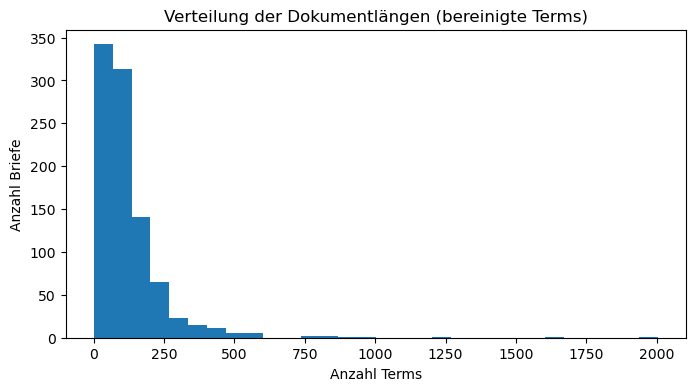

In [5]:
display(df[["n_tokens", "n_terms"]].describe())

plt.figure(figsize=(8, 4))
plt.hist(df["n_terms"], bins=30)
plt.title("Verteilung der Dokumentlängen (bereinigte Terms)")
plt.xlabel("Anzahl Terms")
plt.ylabel("Anzahl Briefe")
plt.show()

## 3. TF-IDF

TF-IDF hilft dabei, Wörter zu identifizieren, die für einzelne Briefe oder für das Korpus charakteristisch sind.

In [6]:
vectorizer = TfidfVectorizer(
    token_pattern=r"(?u)\b\w+\b",
    min_df=3,
    max_df=0.6,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df["clean_text"])
feature_names = vectorizer.get_feature_names_out()

print("TF-IDF-Matrix:", X.shape)

TF-IDF-Matrix: (930, 7962)


In [7]:
def top_tfidf_words(doc_index, n=10):
    row = X[doc_index].toarray().flatten()
    top_ids = row.argsort()[::-1][:n]
    return pd.DataFrame({
        "term": [feature_names[i] for i in top_ids],
        "score": [row[i] for i in top_ids]
    })

doc_index = 0
print("Brief:", df.loc[doc_index, "doc_id"])
top_tfidf_words(doc_index, 10)

Brief: ad_atticum_bx_l10_r440


,term,score
0,pario,0.223502
1,soror,0.168533
2,signum,0.166513
3,comitia,0.159314
4,locus,0.143989
5,confido,0.135665
6,proficiscor facio,0.130256
7,communis amicus,0.130256
8,sponsor appello,0.130256
9,causa magnus,0.130256


### 3.1 Top-Wörter eines ausgewählten Briefs

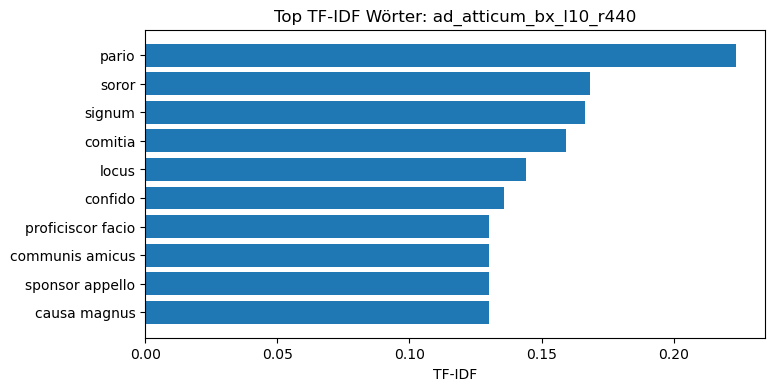

In [8]:
doc_index = 0  # hier ändern

top_doc = top_tfidf_words(doc_index, 10)

plt.figure(figsize=(8, 4))
plt.barh(top_doc["term"][::-1], top_doc["score"][::-1])
plt.title(f"Top TF-IDF Wörter: {df.loc[doc_index, 'doc_id']}")
plt.xlabel("TF-IDF")
plt.show()

### 3.2 Wichtigste TF-IDF-Wörter im gesamten Korpus

,term,score
0,uenio,28.274562
1,puto,26.996753
2,dies,24.859090
3,ago,24.768584
4,dico,24.645316
5,scio,24.627707
6,do,23.051622
7,causa,22.156872
8,magnus,21.985530
9,caesar,21.645382


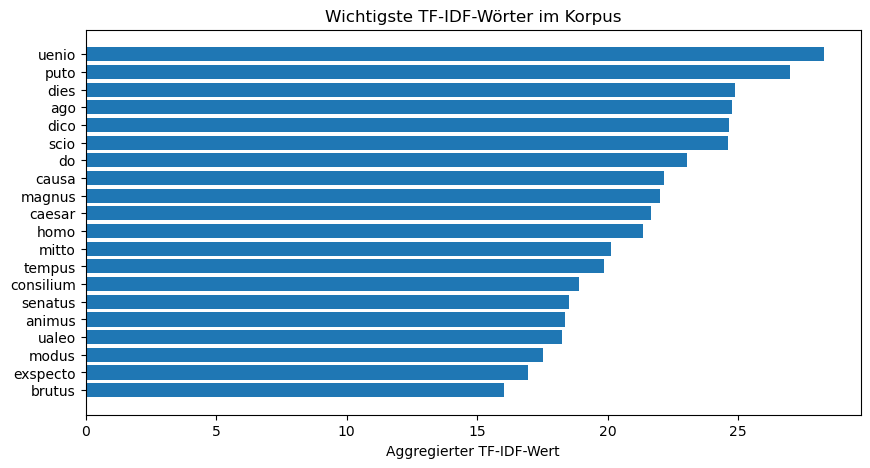

In [9]:
tfidf_sum = np.asarray(X.sum(axis=0)).flatten()
top_ids = tfidf_sum.argsort()[::-1][:20]

top_corpus = pd.DataFrame({
    "term": [feature_names[i] for i in top_ids],
    "score": [tfidf_sum[i] for i in top_ids]
})

display(top_corpus)

plt.figure(figsize=(10, 5))
plt.barh(top_corpus["term"][::-1], top_corpus["score"][::-1])
plt.title("Wichtigste TF-IDF-Wörter im Korpus")
plt.xlabel("Aggregierter TF-IDF-Wert")
plt.show()

### 3.3 Ähnliche Briefe (Cosine Similarity)

In [10]:
sim_matrix = cosine_similarity(X)
sim_df = pd.DataFrame(sim_matrix, index=df["doc_id"], columns=df["doc_id"])

target_doc = df.loc[0, "doc_id"]  # hier ändern
similar_docs = sim_df.loc[target_doc].sort_values(ascending=False)[1:11]

similar_docs

doc_id
ad_atticum_bx_l8_r438              0.226130
ad_atticum_bx_l11_r441             0.152451
ad_atticum_bx_l5_r435              0.146992
ad_quintum_fratrem_b3.0_l1_r896    0.142635
ad_familiares_b7.0_l23_r124        0.138176
ad_familiares_b12.0_l18_r263       0.130368
ad_atticum_bx_l15_r869             0.122387
ad_familiares_b5.0_l2_r59          0.120084
ad_familiares_b1.0_l9_r9           0.117061
ad_atticum_bx_l16_r520             0.113829
Name: ad_atticum_bx_l10_r440, dtype: float64

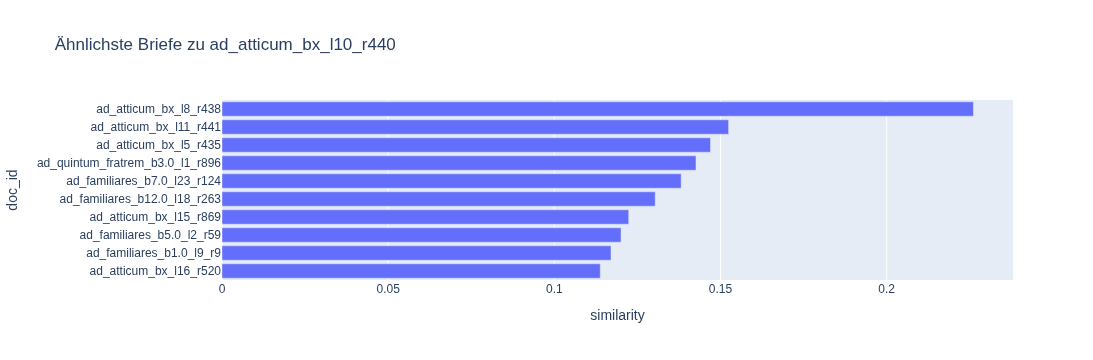

In [11]:
target_doc = df.loc[0, "doc_id"]  # hier ändern
top_sim = sim_df.loc[target_doc].sort_values(ascending=False)[1:11].reset_index()
top_sim.columns = ["doc_id", "similarity"]

fig = px.bar(
    top_sim,
    x="similarity",
    y="doc_id",
    orientation="h",
    title=f"Ähnlichste Briefe zu {target_doc}"
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

### 3.4 Interaktive Similarity-Heatmap (Ausschnitt)

Für grosse Korpora ist die vollständige Matrix schwer lesbar. Daher wird hier nur ein Ausschnitt angezeigt.

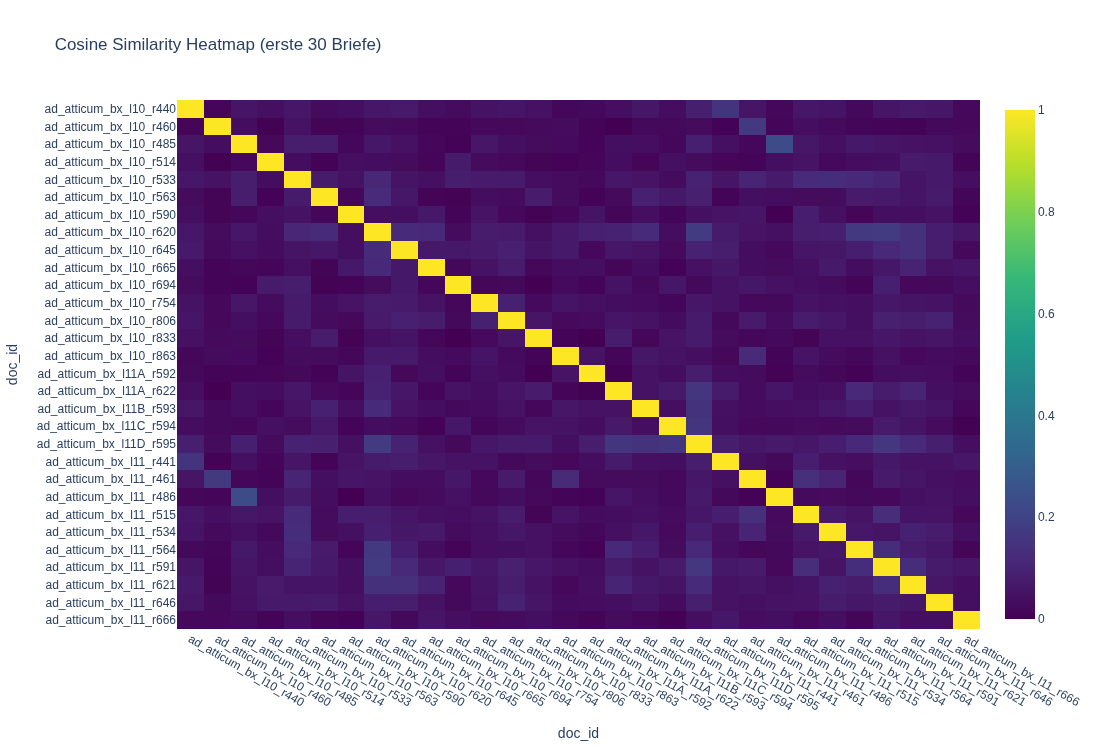

In [13]:
max_docs = min(30, len(df))
heat_df = sim_df.iloc[:max_docs, :max_docs]

fig = px.imshow(
    heat_df,
    aspect="auto",
    title=f"Cosine Similarity Heatmap (erste {max_docs} Briefe)",
    color_continuous_scale="Viridis"
)
fig.update_layout(width=850, height=750)
fig.show()

### 3.5 Interaktives Netzwerk ähnlicher Briefe

Knoten: 342, Kanten: 505


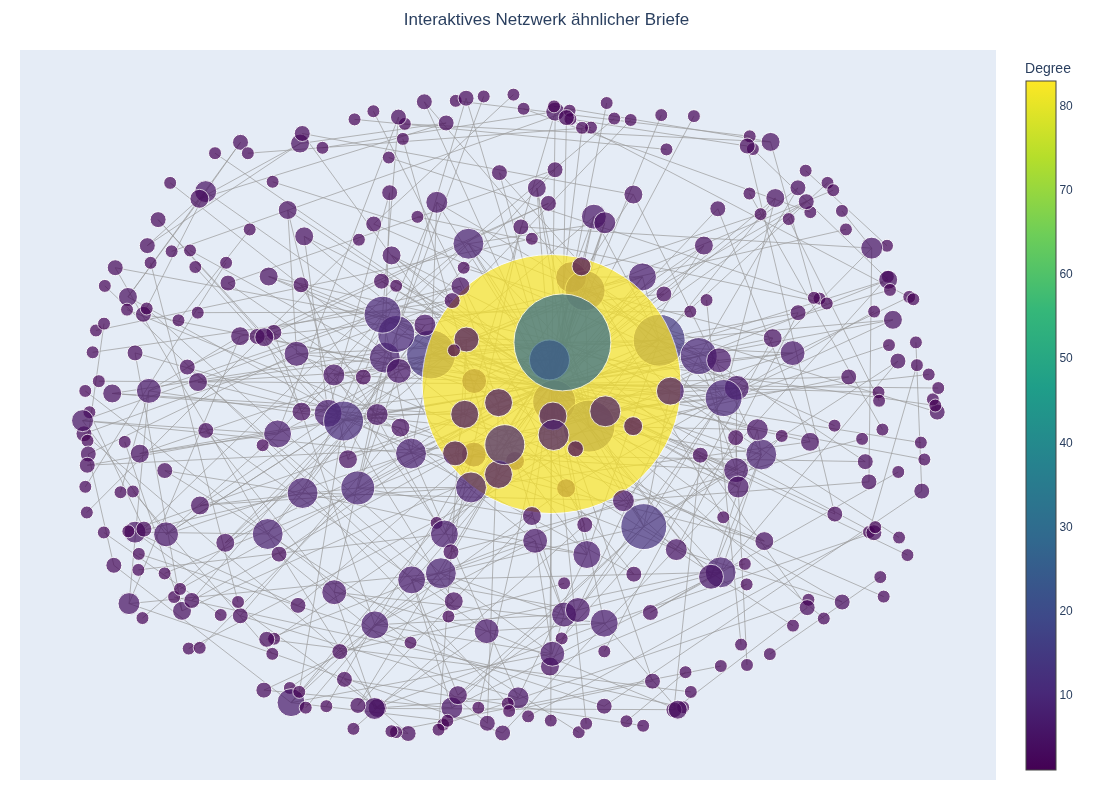

In [14]:
threshold = 0.20

G = nx.Graph()
for doc_id in df["doc_id"]:
    G.add_node(doc_id)

n = len(df)
for i in range(n):
    for j in range(i + 1, n):
        sim = sim_matrix[i, j]
        if sim >= threshold:
            G.add_edge(df.loc[i, "doc_id"], df.loc[j, "doc_id"], weight=float(sim))

G_plot = G.copy()
isolates = list(nx.isolates(G_plot))
G_plot.remove_nodes_from(isolates)

print(f"Knoten: {G_plot.number_of_nodes()}, Kanten: {G_plot.number_of_edges()}")

pos = nx.spring_layout(G_plot, seed=42, k=0.35)

edge_x, edge_y = [], []
for u, v, data in G_plot.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    line=dict(width=0.7, color="#999"),
    hoverinfo="none",
    mode="lines"
)

degrees = dict(G_plot.degree())
node_x, node_y, node_text, node_size, node_color = [], [], [], [], []

for node in G_plot.nodes():
    x, y = pos[node]
    deg = degrees[node]
    node_x.append(x)
    node_y.append(y)
    node_size.append(10 + deg * 3)
    node_color.append(deg)
    node_text.append(f"<b>{node}</b><br>Degree: {deg}")

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers",
    hoverinfo="text",
    hovertext=node_text,
    marker=dict(
        showscale=True,
        colorscale="Viridis",
        color=node_color,
        size=node_size,
        colorbar=dict(title="Degree"),
        line_width=1
    )
)

fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title="Interaktives Netzwerk ähnlicher Briefe",
        title_x=0.5,
        showlegend=False,
        hovermode="closest",
        margin=dict(b=20, l=20, r=20, t=50),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        height=800
    )
)
fig.show()

## 4. Vorbereitung für gensim Topic Modelling

In [15]:
texts = [doc.split() for doc in df["clean_text"]]

dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=3, no_above=0.6)

corpus = [dictionary.doc2bow(text) for text in texts]

print("Dokumente:", len(corpus))
print("Vokabular:", len(dictionary))

Dokumente: 930
Vokabular: 3585


## 5. Topic Modelling mit gensim (LDA)

In [16]:
NUM_TOPICS = 10  # hier experimentieren

lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    passes=15,
    iterations=300,
    random_state=42
)

In [17]:
for i, topic in lda.print_topics(num_topics=NUM_TOPICS, num_words=10):
    print(f"Topic {i}: {topic}")

Topic 0: 0.009*"consilium" + 0.009*"puto" + 0.009*"tempus" + 0.008*"animus" + 0.008*"magnus" + 0.007*"causa" + 0.007*"caesar" + 0.007*"senatus" + 0.007*"dico" + 0.007*"ago"
Topic 1: 0.011*"dico" + 0.011*"fio" + 0.009*"senatus" + 0.009*"puto" + 0.009*"liber" + 0.008*"caesar" + 0.007*"nolo" + 0.007*"do" + 0.007*"consul" + 0.007*"ago"
Topic 2: 0.013*"puto" + 0.011*"scio" + 0.011*"ago" + 0.010*"do" + 0.010*"dico" + 0.010*"dies" + 0.009*"uenio" + 0.009*"causa" + 0.009*"homo" + 0.008*"pompeius"
Topic 3: 0.023*"uenio" + 0.013*"dies" + 0.013*"scio" + 0.012*"mitto" + 0.012*"do" + 0.011*"epistula" + 0.011*"puto" + 0.011*"ago" + 0.010*"exspecto" + 0.009*"dico"
Topic 4: 0.015*"puto" + 0.012*"scio" + 0.011*"uenio" + 0.009*"ualeo" + 0.009*"dies" + 0.008*"dico" + 0.007*"mitto" + 0.007*"do" + 0.007*"tempus" + 0.007*"cura"
Topic 5: 0.014*"caesar" + 0.011*"ago" + 0.010*"magnus" + 0.010*"causa" + 0.009*"animus" + 0.009*"scio" + 0.009*"uenio" + 0.009*"dies" + 0.007*"consul" + 0.007*"homo"
Topic 6: 0.013*"

### 5.1 Kohärenz berechnen

In [18]:
coherence_model = CoherenceModel(
    model=lda,
    texts=texts,
    dictionary=dictionary,
    coherence="c_v"
)

coherence = coherence_model.get_coherence()
print(f"Coherence (c_v): {coherence:.4f}")

/home/phillip/anaconda3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning:

This process (pid=31089) is multi-threaded, use of fork() may lead to deadlocks in the child.

/home/phillip/anaconda3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning:

This process (pid=31089) is multi-threaded, use of fork() may lead to deadlocks in the child.

/home/phillip/anaconda3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning:

This process (pid=31089) is multi-threaded, use of fork() may lead to deadlocks in the child.

/home/phillip/anaconda3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning:

This process (pid=31089) is multi-threaded, use of fork() may lead to deadlocks in the child.

/home/phillip/anaconda3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning:

This process (pid=31089) is multi-threaded, use of fork() may lead to deadlocks in the child.

/home/phillip/anaconda3/lib/python3.12/multiprocessing/

Coherence (c_v): 0.3013


### 5.2 Dominantes Topic pro Brief

In [19]:
def dominant_topic_for_bow(bow):
    topic_probs = lda.get_document_topics(bow, minimum_probability=0.0)
    dominant_topic, dominant_prob = max(topic_probs, key=lambda x: x[1])
    return dominant_topic, dominant_prob

dominant = [dominant_topic_for_bow(bow) for bow in corpus]

df["dominant_topic"] = [x[0] for x in dominant]
df["topic_prob"] = [x[1] for x in dominant]

df[["doc_id", "dominant_topic", "topic_prob"]].head()

,doc_id,dominant_topic,topic_prob
0,ad_atticum_bx_l10_r440,3,0.547042
1,ad_atticum_bx_l10_r460,9,0.960849
2,ad_atticum_bx_l10_r485,3,0.708389
3,ad_atticum_bx_l10_r514,3,0.537006
4,ad_atticum_bx_l10_r533,4,0.992031


### 5.3 Topic-Verteilung visualisieren

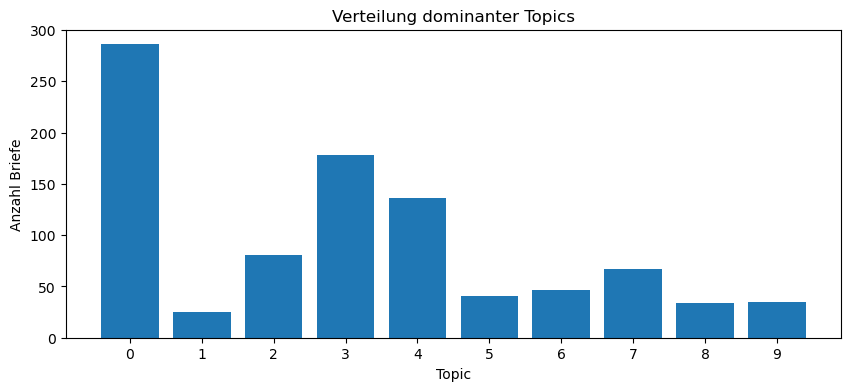

In [20]:
topic_counts = df["dominant_topic"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar(topic_counts.index.astype(str), topic_counts.values)
plt.title("Verteilung dominanter Topics")
plt.xlabel("Topic")
plt.ylabel("Anzahl Briefe")
plt.show()

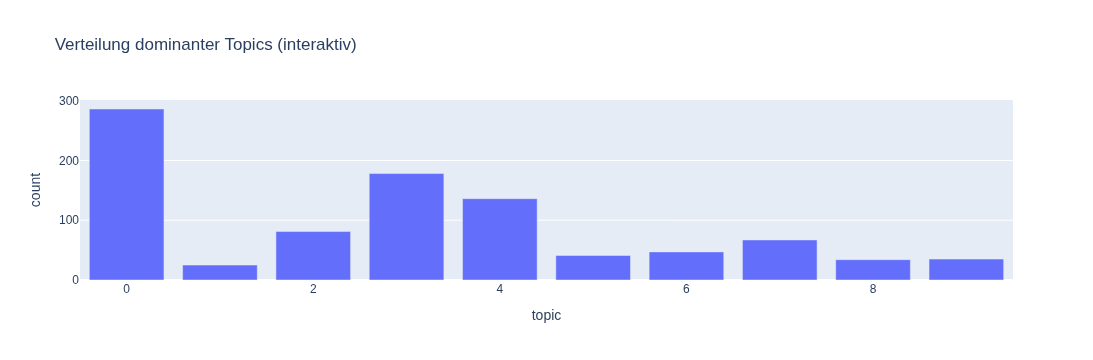

In [21]:
topic_counts_df = topic_counts.reset_index()
topic_counts_df.columns = ["topic", "count"]

fig = px.bar(
    topic_counts_df,
    x="topic",
    y="count",
    title="Verteilung dominanter Topics (interaktiv)"
)
fig.show()

### 5.4 Top-Wörter pro Topic als Balkendiagramme

In [ ]:
top_n = 10
topic_word_rows = []

for topic_id in range(NUM_TOPICS):
    words = lda.show_topic(topic_id, topn=top_n)
    for rank, (word, weight) in enumerate(words, start=1):
        topic_word_rows.append({
            "topic": topic_id,
            "rank": rank,
            "word": word,
            "weight": weight
        })

topic_words_df = pd.DataFrame(topic_word_rows)
topic_words_df.head(20)

In [ ]:
ncols = 2
nrows = int(np.ceil(NUM_TOPICS / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for topic_id in range(NUM_TOPICS):
    ax = axes[topic_id]
    sub = topic_words_df[topic_words_df["topic"] == topic_id].sort_values("weight", ascending=True)
    ax.barh(sub["word"], sub["weight"])
    ax.set_title(f"Topic {topic_id}")
    ax.set_xlabel("Gewicht")

for j in range(NUM_TOPICS, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### 5.5 Dokument-Topic-Matrix

In [ ]:
doc_topic_matrix = []

for bow in corpus:
    topic_probs = lda.get_document_topics(bow, minimum_probability=0.0)
    doc_topic_matrix.append([prob for _, prob in topic_probs])

doc_topic_matrix = np.array(doc_topic_matrix)

topic_cols = [f"topic_{i}" for i in range(NUM_TOPICS)]
doc_topic_df = pd.DataFrame(doc_topic_matrix, columns=topic_cols)
doc_topic_df.insert(0, "doc_id", df["doc_id"].values)

doc_topic_df.head()

In [ ]:
max_docs = min(50, len(doc_topic_df))
heat_data = doc_topic_df.iloc[:max_docs, 1:]

fig = px.imshow(
    heat_data,
    aspect="auto",
    title=f"Dokument-Topic-Heatmap (erste {max_docs} Briefe)",
    color_continuous_scale="Viridis"
)
fig.update_layout(width=900, height=800)
fig.show()

### 5.6 Topic Similarity Heatmap

In [ ]:
topic_word_matrix = lda.get_topics()
topic_similarity = cosine_similarity(topic_word_matrix)

fig = px.imshow(
    topic_similarity,
    text_auto=True,
    title="Ähnlichkeit zwischen Topics",
    color_continuous_scale="Viridis"
)
fig.update_layout(width=700, height=650)
fig.show()

### 5.7 Interaktive pyLDAvis-Visualisierung

In [ ]:
vis = gensimvis.prepare(lda, corpus, dictionary)
pyLDAvis.display(vis)

## 6. Briefe eines bestimmten Topics lesen

Diese Zelle hilft euch, ein Topic historisch zu interpretieren.

In [ ]:
selected_topic = 0  # hier ändern

df[df["dominant_topic"] == selected_topic][["doc_id", "topic_prob", "raw_text"]].sort_values(
    "topic_prob", ascending=False
).head(5)

## 7. Experimentieraufgaben

Probiert mindestens drei Dinge aus:

1. Ändert `NUM_TOPICS` (z. B. 5, 8, 10, 15)
2. Ändert `min_df` und `max_df` im `TfidfVectorizer`
3. Ändert `no_below` und `no_above` im `dictionary.filter_extremes`

Und beantwortet dabei:

- Welche Wörter erscheinen in den TF-IDF-Listen?
- Welche Topics sind historisch sinnvoll?
- Welche Einstellungen liefern interpretierbarere Ergebnisse?
- Wo stossen die Methoden an Grenzen?